MSE : 0.0759354671321544
RMSE: 0.27556390752809845
R2 Score: 0.04745846722337177

Intercept: 0.16157975812196054

Coefficients:
age: 0.1584
hypertension: 0.1055
heart_disease: 0.1005
ever_married: 0.0132
bmi: 0.1742
stroke: 0.0788
gender_Male: 0.0302
gender_Other: -0.0000
work_type_Never_worked: 0.0554
work_type_Private: 0.0119
work_type_Self-employed: 0.0061
work_type_children: 0.0984
Residence_type_Urban: -0.0057
smoking_status_formerly smoked: 0.0166
smoking_status_never smoked: 0.0162
smoking_status_smokes: 0.0123
high_glucose: 0.0000
age_group_Unknown: 0.0000
bmi_category_Unknown: 0.3235


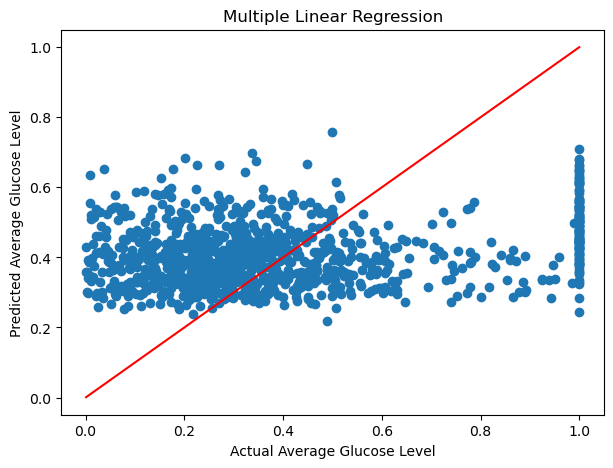

In [11]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    r"C:\Users\NANDHANA\Desktop\AI_ML_LAB\stroke_preprocessed.csv"
)

# Convert existing boolean columns
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

# Remove ID
df = df.drop("id", axis=1)

# Handle missing categorical values
df["age_group"] = df["age_group"].fillna("Unknown")
df["bmi_category"] = df["bmi_category"].fillna("Unknown")

# Convert categorical variables into dummy variables
df = pd.get_dummies(df, drop_first=True)

# Convert all columns to numeric
df = df.astype(float)

# Features
X = df.drop("avg_glucose_level", axis=1)

# Target
y = df["avg_glucose_level"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Coefficients
print("\nIntercept:", model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

# Actual vs Predicted
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Average Glucose Level")
plt.ylabel("Predicted Average Glucose Level")
plt.title("Multiple Linear Regression")
plt.show()